# **Urban Cycling Route Planner**

Using the OpenStreetMap API, we created code that can query and store bicycle infrastructure to be able to run algorithms on the data. 

We set up a data structure using nodes and edges defining a directed graph structure. Then we implented Dijkstra's algorithm, A* and these same functions using NetworkX. 


The data is filtered from the API using the text in the query.txt. Query parameters can be changed there.

In this notebook you can try the path finding using an interactive map, check out benchmarking results and bottlenecks in the infrastructure using betweenness centrality.

In [2]:
from data_handler import fill_data
from algorithms_networkx import convert_to_networkx, betweenness_centrality
from visualize import interactive_map, runtime_graph, explored_graph, draw_points
from benchmark import run_benchmark, test

With this section, running the script, you can view a desired area thats included in the overpass dataset with a generated map of the area.
Selecting two points and clicking the button will generate the route between the two points (if exists) and save it to route.html using folium.

The error "Error fetching data" is because of the API-s error/limitation. If this error occurs, run the code again.

In [3]:
area = "Budapest" # change this to anything you like
network = fill_data(area)

if network == "error":
    print("Error fetching data")
else:
    graph = convert_to_networkx(network)
    map = interactive_map(network, graph)
    display(map) 

## Benchmark

We benchmark our Dijkstra, A* and Networkxs algorithm against given desired areas.

This section runs a benchmark on the given areas in increasing order by size. It compares the different pathfinding algorithms from both our code and NetworkX's built-in functions.

Just like in the previous cell, "Error fetching data" is the API-s error/limitation.

In [4]:
areas = [
    "IX. kerület",        # smaller district
    "XI. kerület",        # medium district
    "Budapest",           # full city
    "Amsterdam",          # larger city
]
results = run_benchmark(areas, 50)

Benchmarking 1417 nodes:
Result: Dijkstra: 0.00025  A*: 0.00018  NetworkX - Dijkstra: 0.00026 NetworkX - A*: 0.00025
Benchmarking 4615 nodes:
Result: Dijkstra: 0.00141  A*: 0.00094  NetworkX - Dijkstra: 0.00228 NetworkX - A*: 0.00126
Benchmarking 27913 nodes:
Result: Dijkstra: 0.00696  A*: 0.00294  NetworkX - Dijkstra: 0.01222 NetworkX - A*: 0.00676
Benchmarking 67235 nodes:
Result: Dijkstra: 0.03372  A*: 0.01009  NetworkX - Dijkstra: 0.09063 NetworkX - A*: 0.01789


You can create a graph of the mesured runtimes, making it visibly easy to compare them.

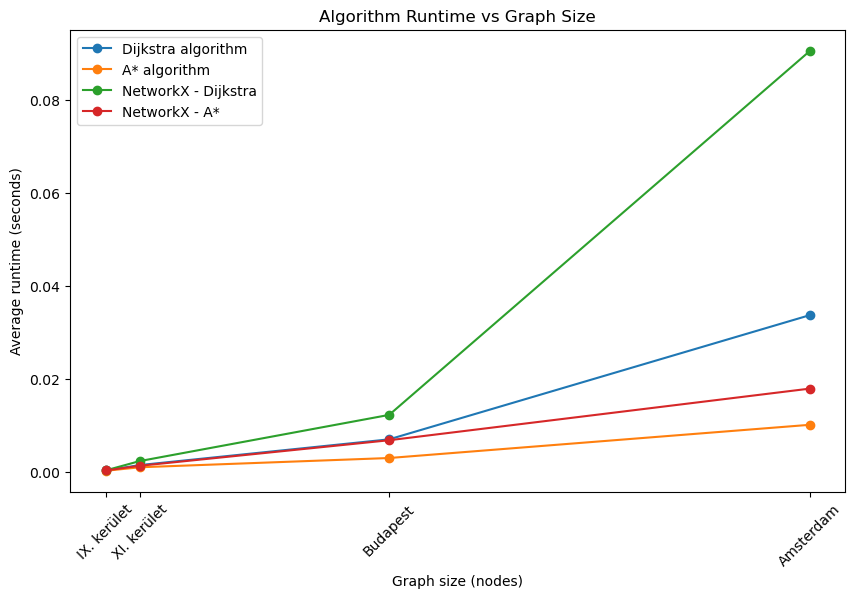

In [5]:
runtime_graph(results)

We have also created a graph which depicts the amount of nodes that each pathfinding went through to reach the final path.

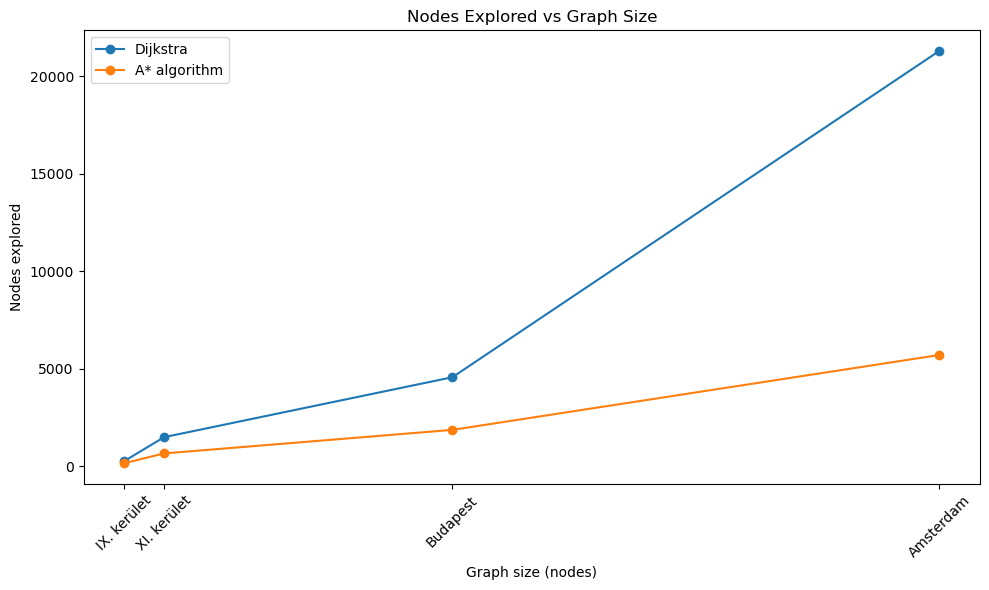

In [6]:
explored_graph(results)

With this section, we check the correctness of the algorithms. We check if all algorithms return the same path and the same distance.

In [7]:
test()

The algorithms return the same path and distance.


Here, you can find the most visited Node in the dataset. These nodes are the bottlenecks of the infrastructure. It runs based on a given 'n' amount of times, that is 1 by default, for demonstration purposes.

Higher n-s take longer time because of the size of the network. Still, the code is prepared to handle the case when n is not 1.

In [8]:
area = 'Budapest' # change this to anything you like
network1 = fill_data(area)
if network1 == "error":
    print("Error fetching data")
else:
    n = 15 # change this to anything you like
    graph = convert_to_networkx(network1)
    points = betweenness_centrality(graph, n)
    print(f'The point(s): {points}')
    draw_points(network1, list(points))

The point(s): {1416981972: 13, 262075658: 1, 74959980: 1}
Point(s) saved to centrality.html
